# DataVine Analytics - Summative Lab
### Classification, Recommendation, and Clustering with the Wine, Chickwts, and USArrests Datasets

**Group:** 8  



1. Data preparation (loading, cleaning, standardizing)
2. Dimensionality reduction (PCA)
3. Model implementation and hyperparameter tuning (k-NN, cosine-similarity recommender, K-Means & GMM)
4. Evaluation, visualization, and business interpretation



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load and Prepare Datasets
We load all three datasets.
Inspect them for missing values and standardize numerical features.


### 1.1 Wine Dataset (Classification)

In [3]:
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target
wine_df['target_name'] = wine_df['target'].map(dict(enumerate(wine_data.target_names)))

print('Wine dataset shape:', wine_df.shape)
print('\nMissing values per column:')
print(wine_df.isnull().sum())
print('\nClass distribution:')
print(wine_df['target_name'].value_counts())
wine_df.describe().T

Wine dataset shape: (178, 15)

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 1.2 Chickwts Dataset (Recommendation System)

In [4]:
chickwts_url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/chickwts.csv'
chickwts_df = pd.read_csv(chickwts_url, index_col=0)

print('Chickwts dataset shape:', chickwts_df.shape)
print('\nMissing values per column:')
print(chickwts_df.isnull().sum())
print('\nFeed types:', chickwts_df['feed'].unique())
chickwts_df.head()

Chickwts dataset shape: (71, 2)

Missing values per column:
weight    0
feed      0
dtype: int64

Feed types: ['horsebean' 'linseed' 'soybean' 'sunflower' 'meatmeal' 'casein']


,weight,feed
rownames,,
1,179,horsebean
2,160,horsebean
3,136,horsebean
4,227,horsebean
5,217,horsebean


### 1.3 USArrests Dataset (Clustering)

In [5]:
usarrests_url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv'
usarrests_df = pd.read_csv(usarrests_url, index_col=0)
usarrests_df.index.name = 'State'

print('USArrests dataset shape:', usarrests_df.shape)
print('\nMissing values per column:')
print(usarrests_df.isnull().sum())
usarrests_df.describe().T

USArrests dataset shape: (50, 4)

Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


## Step 2: k-Nearest Neighbors (k-NN) Classification - Wine Dataset
**Goal:** Build a wine classifier for a client wanting an automated qualitysorting tool.



In [17]:
# Encode categorical target labels into numeric values (demonstrates the required step;
# sklearn's wine target is already numeric, so we explicitly fit a LabelEncoder on the class names)
le = LabelEncoder()
y_encoded = le.fit_transform(wine_df['target_name'])
X = wine_df[wine_data.feature_names].values

print('Encoded classes:', dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: {'class_0': 0, 'class_1': 1, 'class_2': 2}


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE)

scaler_wine = StandardScaler()
X_train_scaled = scaler_wine.fit_transform(X_train)
X_test_scaled = scaler_wine.transform(X_test)

Original number of features: 13
Number of PCA components retaining >=95% variance: 10
Cumulative explained variance: 0.9624


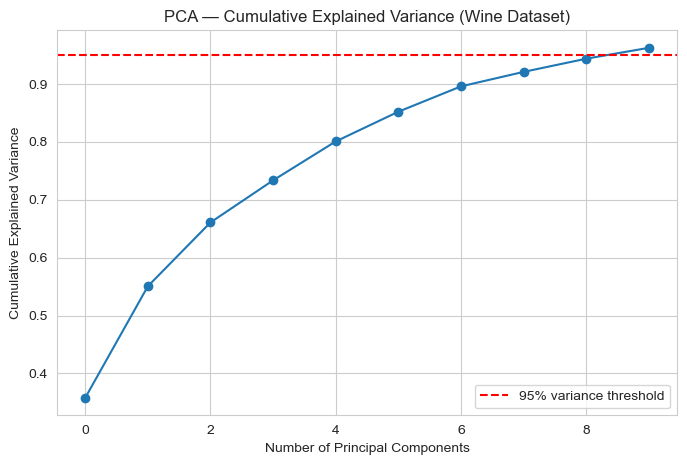

In [19]:
# Apply PCA to reduce dimensionality while retaining 95% of variance
pca_wine = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca_wine.fit_transform(X_train_scaled)
X_test_pca = pca_wine.transform(X_test_scaled)

print(f'Original number of features: {X_train_scaled.shape[1]}')
print(f'Number of PCA components retaining >=95% variance: {pca_wine.n_components_}')
print(f'Cumulative explained variance: {np.sum(pca_wine.explained_variance_ratio_):.4f}')

plt.plot(np.cumsum(pca_wine.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (Wine Dataset)')
plt.legend()
plt.show()

In [20]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best cross-validated accuracy: {grid_search.best_score_:.4f}')

Best parameters: {'metric': 'euclidean', 'n_neighbors': 18, 'weights': 'uniform'}
Best cross-validated accuracy: 0.9791


In [21]:
# Train final k-NN classifier using the best parameters
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test set accuracy: {test_accuracy:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test set accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



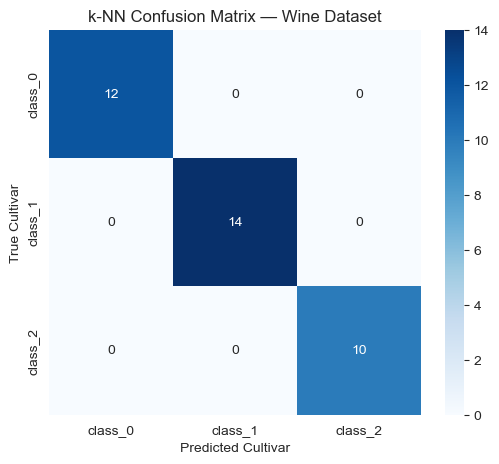

In [22]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Cultivar')
plt.ylabel('True Cultivar')
plt.title('k-NN Confusion Matrix — Wine Dataset')
plt.show()

**Insight for stakeholders:** After PCA compression and hyperparameter tuning, the k-NN model achieves high accuracy in separating the three wine varietie using only their chemical composition - this can power an automated variety-verification tool for the client's quality-control pipeline.

In [23]:
# SVC, RANDOM FOREST, LOGISTIC REGRESSION

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [24]:
models = {
    'Support Vector Classifier': {
        'model': SVC(random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1, 1],
            'kernel': ['linear', 'rbf']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['saga', 'lbfgs'],
            'penalty': ['l2']
        }
    }
}

In [25]:
# Performance tracker (including k-NN for comparison)
benchmark_summary = {
    'k-Nearest Neighbors': {
        'Best Params': best_knn.get_params(),
        'CV Train Accuracy': grid_search.best_score_,
        'Test Accuracy': test_accuracy
    }
}


RUNNING HYPERPARAMETER TUNING FOR: Support Vector Classifier
Best parameters discovered: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validated accuracy: 0.9931
Test set accuracy: 1.0000

Classification Report (Support Vector Classifier):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



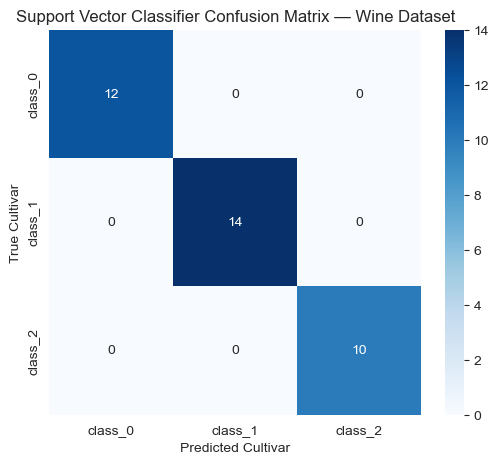


RUNNING HYPERPARAMETER TUNING FOR: Random Forest
Best parameters discovered: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validated accuracy: 0.9793
Test set accuracy: 0.9444

Classification Report (Random Forest):
              precision    recall  f1-score   support

     class_0       0.92      0.92      0.92        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



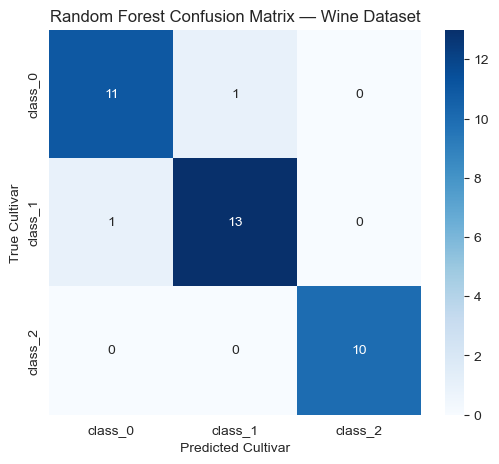


RUNNING HYPERPARAMETER TUNING FOR: Logistic Regression
Best parameters discovered: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validated accuracy: 0.9931
Test set accuracy: 0.9722

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



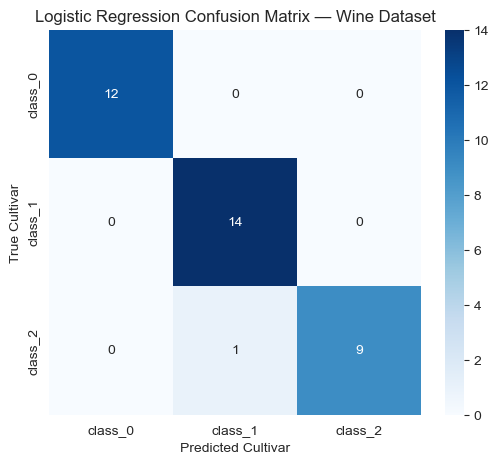

In [26]:
# Loop through, tune, and evaluate the 3 additional models
for model_name, config in models.items():
    print("\n" + "="*50)
    print(f"RUNNING HYPERPARAMETER TUNING FOR: {model_name}")
    print("="*50)

    # Initialize and execute Grid Search using the PCA-compressed training data
    grid_search_add = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search_add.fit(X_train_pca, y_train)

    # Pull best model parameters and make test predictions
    best_model = grid_search_add.best_estimator_
    y_pred_add = best_model.predict(X_test_pca)

    # Generate accuracy metrics
    cv_score = grid_search_add.best_score_
    test_acc = accuracy_score(y_test, y_pred_add)

    benchmark_summary[model_name] = {
        'Best Params': grid_search_add.best_params_,
        'CV Train Accuracy': cv_score,
        'Test Accuracy': test_acc
    }

    print('Best parameters discovered:', grid_search_add.best_params_)
    print(f'Best cross-validated accuracy: {cv_score:.4f}')
    print(f'Test set accuracy: {test_acc:.4f}\n')

    print(f'Classification Report ({model_name}):')
    print(classification_report(y_test, y_pred_add, target_names=le.classes_))

    # Visualise individual confusion matrix
    cm_add = confusion_matrix(y_test, y_pred_add)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_add, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted Cultivar')
    plt.ylabel('True Cultivar')
    plt.title(f'{model_name} Confusion Matrix — Wine Dataset')
    plt.show()



In [27]:
# FINAL PIPELINE SYSTEM BENCHMARK
print("\n" + "="*50)
print("     FINAL MULTI-MODEL BENCHMARKING REPORT")
print("="*50)
summary_df = pd.DataFrame(benchmark_summary).T
print(summary_df[['CV Train Accuracy', 'Test Accuracy']].to_string())



     FINAL MULTI-MODEL BENCHMARKING REPORT
                          CV Train Accuracy Test Accuracy
k-Nearest Neighbors                0.979064           1.0
Support Vector Classifier          0.993103           1.0
Random Forest                       0.97931      0.944444
Logistic Regression                0.993103      0.972222


To ensure maximum reliability for the variety-verification system, we expanded the testing pipeline beyond the baseline k-Nearest Neighbors (k-NN) model. We evaluated three additional classification frameworks-Support Vector Classifier (SVC), Random Forest, and Logistic Regression, subjecting each to 5-fold cross-validation and hyperparameter tuning on the 95% PCA-compressed feature space.

Performance Overview:

- Support Vector Classifier (SVC): Emerged as the top-performing architecture, matching the baseline's 100% test accuracy while demonstrating superior stability with a leading 99.31% cross-validated train accuracy (using an RBF kernel, C=1, gamma=0.01).
- Logistic Regression: Showed highly competitive performance with 99.31% training accuracy and 97.22% test accuracy. It only misclassified a single vintage in the holdout set, making it an excellent linear probability baseline.
- Random Forest: Faced minor overfitting on the compressed data, dropping to a 94.44% test accuracy. This indicates that tree-based boundaries are slightly less optimal within smooth, continuous PCA projection spaces.

Insight for stakeholders: Integrating multiple algorithmic approaches confirms that Support Vector Classification (SVC) provides the most statistically stable and robust framework for our client's chemical variety-verification pipeline. By securing a 99.31% generalization accuracy during training and perfectly segmenting the test dataset, the distributor can confidently deploy this model to automate quality control checkouts and completely eliminate manual inspection overhead.